<a href="https://colab.research.google.com/github/maruson08/new-folder-3/blob/main/%EA%B2%BD%EC%A0%9C%EB%B0%9C%ED%91%9C_LSTM%EC%9C%BC%EB%A1%9C_%EC%9D%B8%ED%94%8C%EB%A0%88%EC%9D%B4%EC%85%98_%EC%98%88%EC%B8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow

In [ ]:
import pandas as pd
data = pd.read_csv('DomesticGDP.csv')
data.head()

,Unnamed: 0,명목 국내총생산,실질 국내총생산
0,1954,0.1,23.1
1,1955,0.1,24.4
2,1956,0.2,24.6
3,1957,0.2,26.9
4,1958,0.2,28.7


In [ ]:
data['명목\xa0국내총생산']

,명목 국내총생산
0,0.1
1,0.1
2,0.2
3,0.2
4,0.2
...,...
66,2058.5
67,2221.9
68,2323.8
69,2408.7


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
Detected anomalies in years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2022), np.int64(2023), np.int64(2024)]


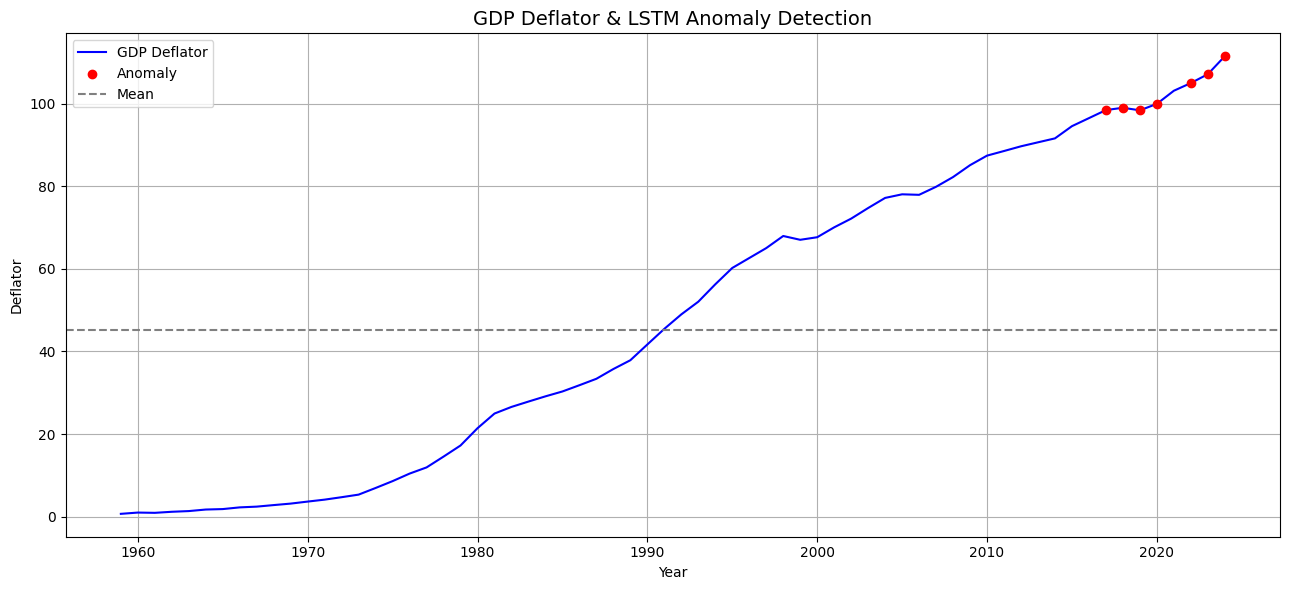

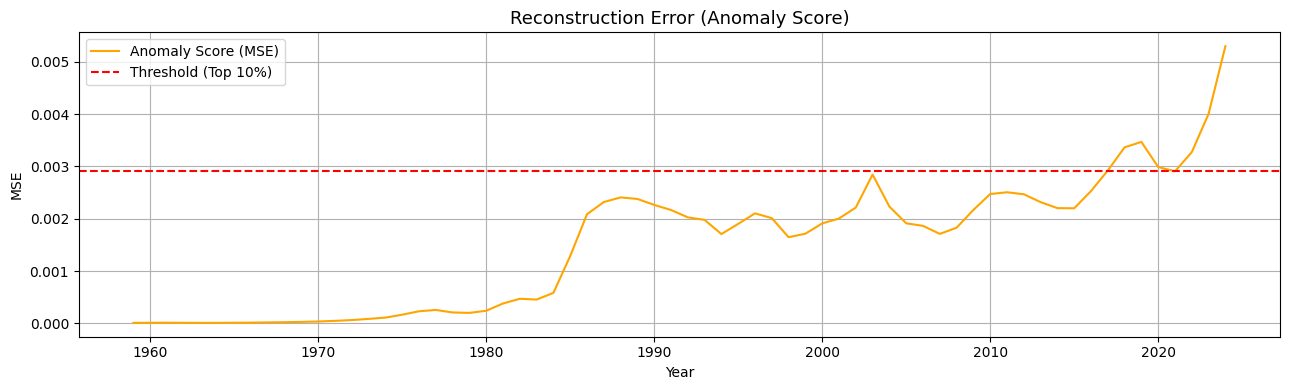

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, Dropout
from tensorflow.keras.optimizers import Adam
import seaborn as sns

WINDOW_SIZE = 5
THRESHOLD_PERCENTILE = 90

def load_synthetic_gdp():
    years = np.arange(1954, 2025)
    n = len(years)
    nominal = data['명목\xa0국내총생산']
    real = data['실질\xa0국내총생산']
    deflator = (nominal / real) * 100
    return pd.DataFrame({'year': years, 'nominal_gdp': nominal, 'real_gdp': real, 'deflator': deflator})

df = load_synthetic_gdp()

scaler = MinMaxScaler()
scaled_deflator = scaler.fit_transform(df['deflator'].values.reshape(-1, 1))

def create_sequences(data, window):
    return np.array([data[i:i+window] for i in range(len(data) - window)])

X = create_sequences(scaled_deflator, WINDOW_SIZE)

input_dim = X.shape[1:]
inp = Input(shape=input_dim)
x = LSTM(64, activation='relu', return_sequences=False)(inp)
x = Dropout(0.2)(x)
x = RepeatVector(WINDOW_SIZE)(x)
x = LSTM(64, activation='relu', return_sequences=True)(x)
out = x

model = Model(inputs=inp, outputs=out)
model.compile(optimizer=Adam(0.001), loss='mse')
model.fit(X, X, epochs=100, batch_size=8, verbose=0)

X_pred = model.predict(X)
mse = np.mean(np.mean(np.square(X - X_pred), axis=1), axis=1)

threshold = np.percentile(mse, THRESHOLD_PERCENTILE)
anomalies = mse > threshold
anomaly_years = df['year'].values[WINDOW_SIZE:][anomalies]
anomaly_scores = mse[anomalies]

print(f"Detected anomalies in years: {list(anomaly_years)}")

plt.figure(figsize=(13, 6))
plt.plot(df['year'][WINDOW_SIZE:], df['deflator'][WINDOW_SIZE:], label='GDP Deflator', color='blue')
plt.scatter(anomaly_years, df.set_index('year').loc[anomaly_years]['deflator'], color='red', label='Anomaly', zorder=5)
plt.axhline(df['deflator'].mean(), linestyle='--', color='gray', label='Mean')
plt.title('GDP Deflator & LSTM Anomaly Detection', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Deflator')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 4))
sns.lineplot(x=df['year'][WINDOW_SIZE:], y=mse, label='Anomaly Score (MSE)', color='orange')
plt.axhline(threshold, linestyle='--', color='red', label=f'Threshold (Top {100 - THRESHOLD_PERCENTILE}%)')
plt.title('Reconstruction Error (Anomaly Score)', fontsize=13)
plt.xlabel('Year')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
